In [1]:
%load_ext autoreload
%autoreload 3
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import sys, warnings
import numpy as np

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/')
from config import SPE1_PICKLE_ROOT
from mlm_pop_ridge_utils import (
    build_meta_df,
    run_all_meta_regressions,
    plot_population_effects,
    plot_metadata_effects,
    plot_credible_pairs,
    META_NAMES, META_LABELS,
)
from pop_ridge_utils import load_population_results, aggregate_population
from ridge_regression_utils import FEAT_LABELS

warnings.filterwarnings('ignore')

In [2]:
# ── Configuration ──────────────────────────────────────────────────────────────
RIDGE_PICKLE_DIR = SPE1_PICKLE_ROOT + '/ridge_regression_pickles'
MLM_SAVE_PATH    = RIDGE_PICKLE_DIR + '/mlm_meta_regression_results.pkl'

CI              = 0.94   # confidence interval width
FDR_Q           = 0.05
FORCE_RECOMPUTE = True   # set False after first run

In [3]:
# ── Load population results ────────────────────────────────────────────────────
all_results, cell_ids, target_names, predictor_sets = load_population_results(RIDGE_PICKLE_DIR)
_, _, beta_pop = aggregate_population(all_results, cell_ids, target_names, predictor_sets)

feat_labels   = FEAT_LABELS
target_labels = (
    [f'Pre {l}'     for l in feat_labels] +
    [f'Pre−BL {l}'  for l in feat_labels] +
    [f'Post {l}'    for l in feat_labels] +
    [f'Post−BL {l}' for l in feat_labels] +
    [f'Δ {l}'       for l in feat_labels]
)

print(f'{len(cell_ids)} cells  |  {len(target_names)} targets')

Loaded 37 cells  |  25 targets  |  3 predictor sets
37 cells  |  25 targets


In [4]:
# ── Build metadata matrix ──────────────────────────────────────────────────────
meta_df = build_meta_df(cell_ids)
print(meta_df.describe())
meta_df.head()

           is_IN      is_WC      is_IC  cort_depth_z  dark_neuron  eap_visible
count  37.000000  37.000000  37.000000  3.700000e+01    37.000000    37.000000
mean    0.135135   0.135135   0.351351  2.025407e-16     0.189189     0.513514
std     0.346583   0.346583   0.483978  1.000000e+00     0.397061     0.506712
min     0.000000   0.000000   0.000000 -2.486570e+00     0.000000     0.000000
25%     0.000000   0.000000   0.000000 -4.778894e-01     0.000000     0.000000
50%     0.000000   0.000000   0.000000 -3.242770e-02     0.000000     1.000000
75%     0.000000   0.000000   1.000000  7.403187e-01     0.000000     1.000000
max     1.000000   1.000000   1.000000  1.992995e+00     1.000000     1.000000


,cell_id,is_IN,is_WC,is_IC,cort_depth_z,dark_neuron,eap_visible
0,c10,0,0,0,-1.407877,0,0
1,c12,1,0,0,-0.463774,0,1
2,c13,0,0,0,-0.382363,1,0
3,c14,0,0,0,-1.084531,0,1
4,c15,0,0,0,-1.729253,1,1


In [5]:
# ── Run MLM meta-regression (OLS + HC3 robust SEs + FDR) ─────────────────────
# 200 models (25 targets × 8 features). Runs in seconds.
# FDR applied across all 200 intercept p-values, and separately per metadata variable.
df_mlm = run_all_meta_regressions(
    beta_pop, meta_df, target_names, target_labels,
    ci=CI, fdr_q=FDR_Q,
    save_path=MLM_SAVE_PATH, force_recompute=FORCE_RECOMPUTE,
)
print(df_mlm.shape)
df_mlm.head()

Meta-regression (OLS + HC3): 100%|██████████| 200/200 [00:00<00:00, 1202.61it/s]


Population intercept: 0 / 200 FDR-significant
  Cell type
(IN vs PC): 0 / 200 FDR-significant
  Patch type
(WC vs Juxta): 0 / 200 FDR-significant
  Current type
(IC vs VC): 0 / 200 FDR-significant
  Cort. depth (z)     : 0 / 200 FDR-significant
  Dark neuron         : 0 / 200 FDR-significant
  EAP visible         : 0 / 200 FDR-significant

Saved: mlm_meta_regression_results.pkl
(200, 46)


,target,target_label,feature,n_cells,mu_mean,mu_ci_lo,mu_ci_hi,mu_pval,gamma_is_IN,gamma_is_IN_lo,...,gamma_is_WC_pval_fdr,gamma_is_WC_sig_fdr,gamma_is_IC_pval_fdr,gamma_is_IC_sig_fdr,gamma_cort_depth_z_pval_fdr,gamma_cort_depth_z_sig_fdr,gamma_dark_neuron_pval_fdr,gamma_dark_neuron_sig_fdr,gamma_eap_visible_pval_fdr,gamma_eap_visible_sig_fdr
0,pre_lfp_amp,Pre LFP Amp,Ramp Amp,37,-0.019538,-0.042322,0.003246,0.106775,0.006708,-0.064104,...,0.947155,False,0.861834,False,0.988132,False,0.905729,False,0.998859,False
1,pre_lfp_amp,Pre LFP Amp,Infl. Time,37,0.006274,-0.017317,0.029866,0.616929,-0.040018,-0.116594,...,0.947155,False,0.960693,False,0.966266,False,0.999196,False,0.998859,False
2,pre_lfp_amp,Pre LFP Amp,Infl. Amp,37,0.019835,-0.037957,0.077627,0.518594,-0.036309,-0.108305,...,0.959506,False,0.861834,False,0.966266,False,0.905729,False,0.998859,False
3,pre_lfp_amp,Pre LFP Amp,Peak Amp,37,0.028105,-0.125008,0.181217,0.729921,-0.029467,-0.359624,...,0.947155,False,0.861834,False,0.966266,False,0.905729,False,0.998859,False
4,pre_lfp_amp,Pre LFP Amp,Peak Width,37,0.011588,-0.068237,0.091412,0.784838,-0.055932,-0.173338,...,0.947155,False,0.931710,False,0.966266,False,0.905729,False,0.998859,False


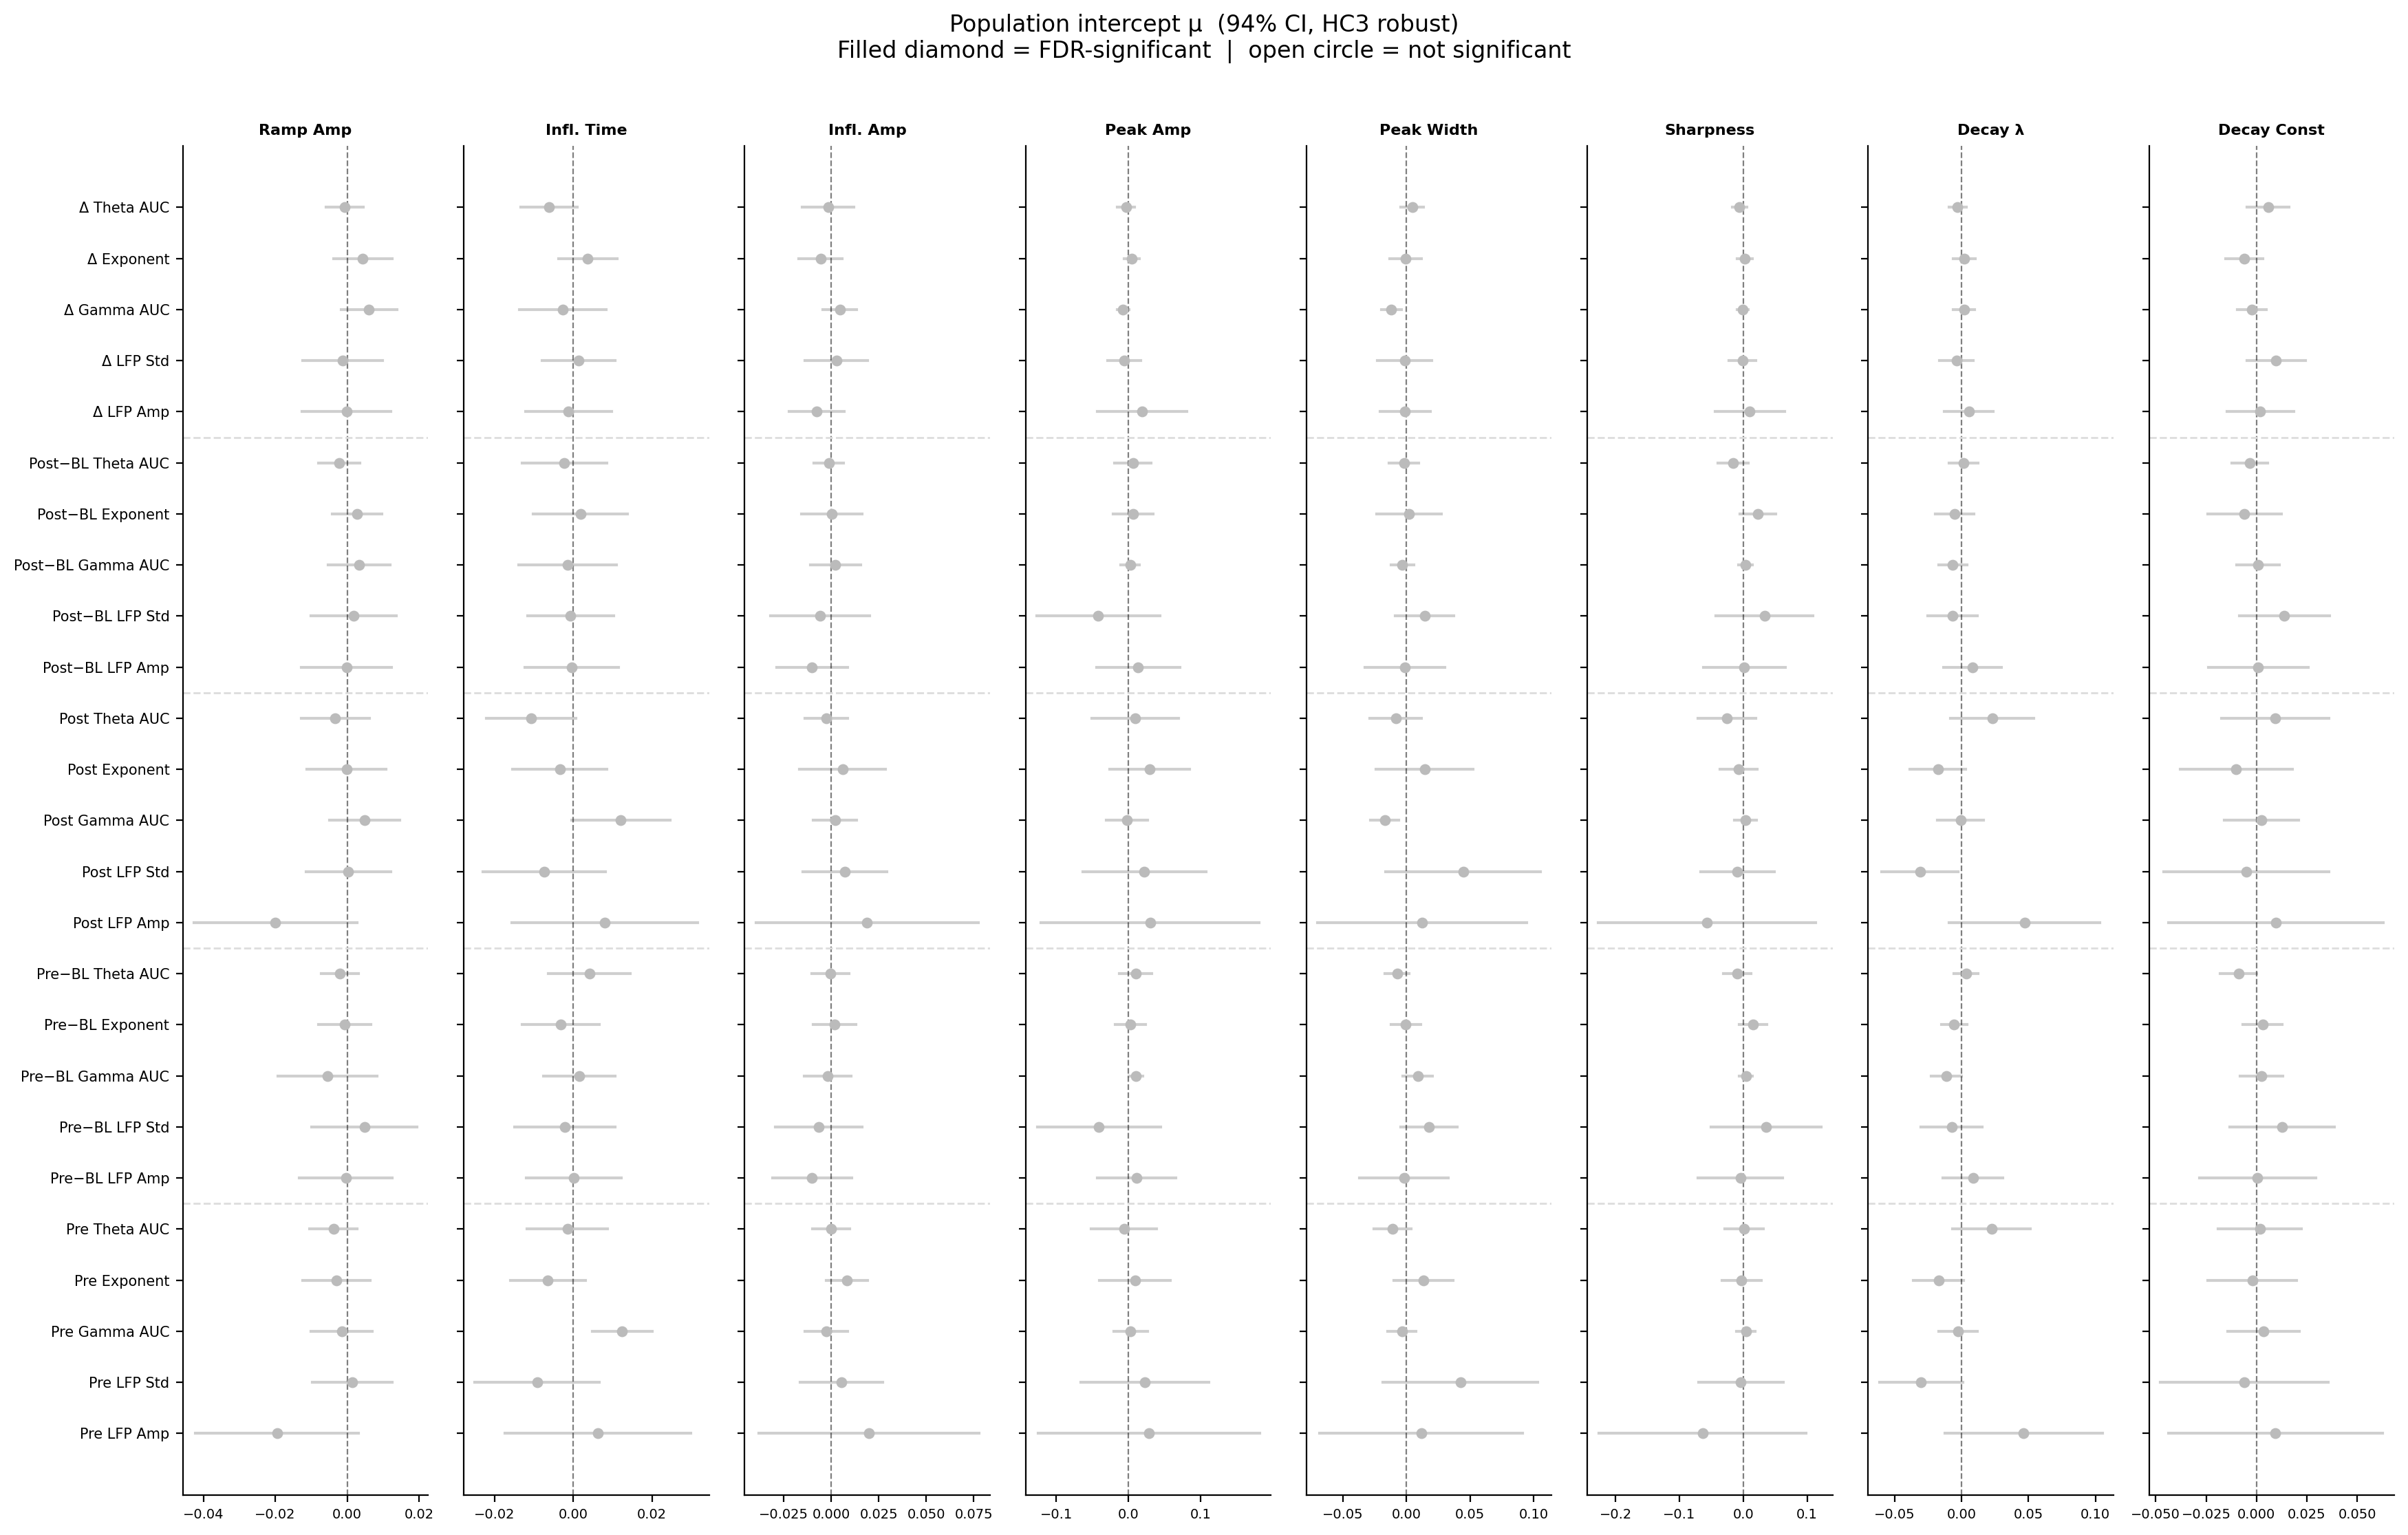

In [6]:
# ── Population intercept forest plot ──────────────────────────────────────────
# μ + 94% CI for every (target × feature) pair.
# Filled diamond = FDR-significant. Red = positive, Blue = negative.
plot_population_effects(df_mlm, target_labels)

In [7]:
# ── FDR-significant population effects ───────────────────────────────────────
plot_credible_pairs(df_mlm)

No FDR-significant population effects.

Top 10 by raw p-value (none survived FDR):
    target_label     feature   mu_mean  mu_ci_lo  mu_ci_hi  mu_pval  mu_pval_fdr
   Pre Gamma AUC  Infl. Time  0.012465  0.004867  0.020064 0.002032     0.308703
  Post Gamma AUC  Peak Width -0.017052 -0.027890 -0.006213 0.003087     0.308703
     Δ Gamma AUC  Peak Width -0.011720 -0.019731 -0.003709 0.005932     0.395437
    Post LFP Std     Decay λ -0.031057 -0.059500 -0.002613 0.040014     0.990282
Pre−BL Gamma AUC    Peak Amp  0.009936  0.000237  0.019635 0.054020     0.990282
Pre−BL Gamma AUC     Decay λ -0.011415 -0.022810 -0.000021 0.059541     0.990282
Pre−BL Theta AUC Decay Const -0.008891 -0.017948  0.000167 0.064869     0.990282
     Pre LFP Std     Decay λ -0.030279 -0.061448  0.000890 0.067683     0.990282
  Post Gamma AUC  Infl. Time  0.012064 -0.000440  0.024568 0.069585     0.990282
  Post Theta AUC  Infl. Time -0.010683 -0.021980  0.000615 0.075338     0.990282


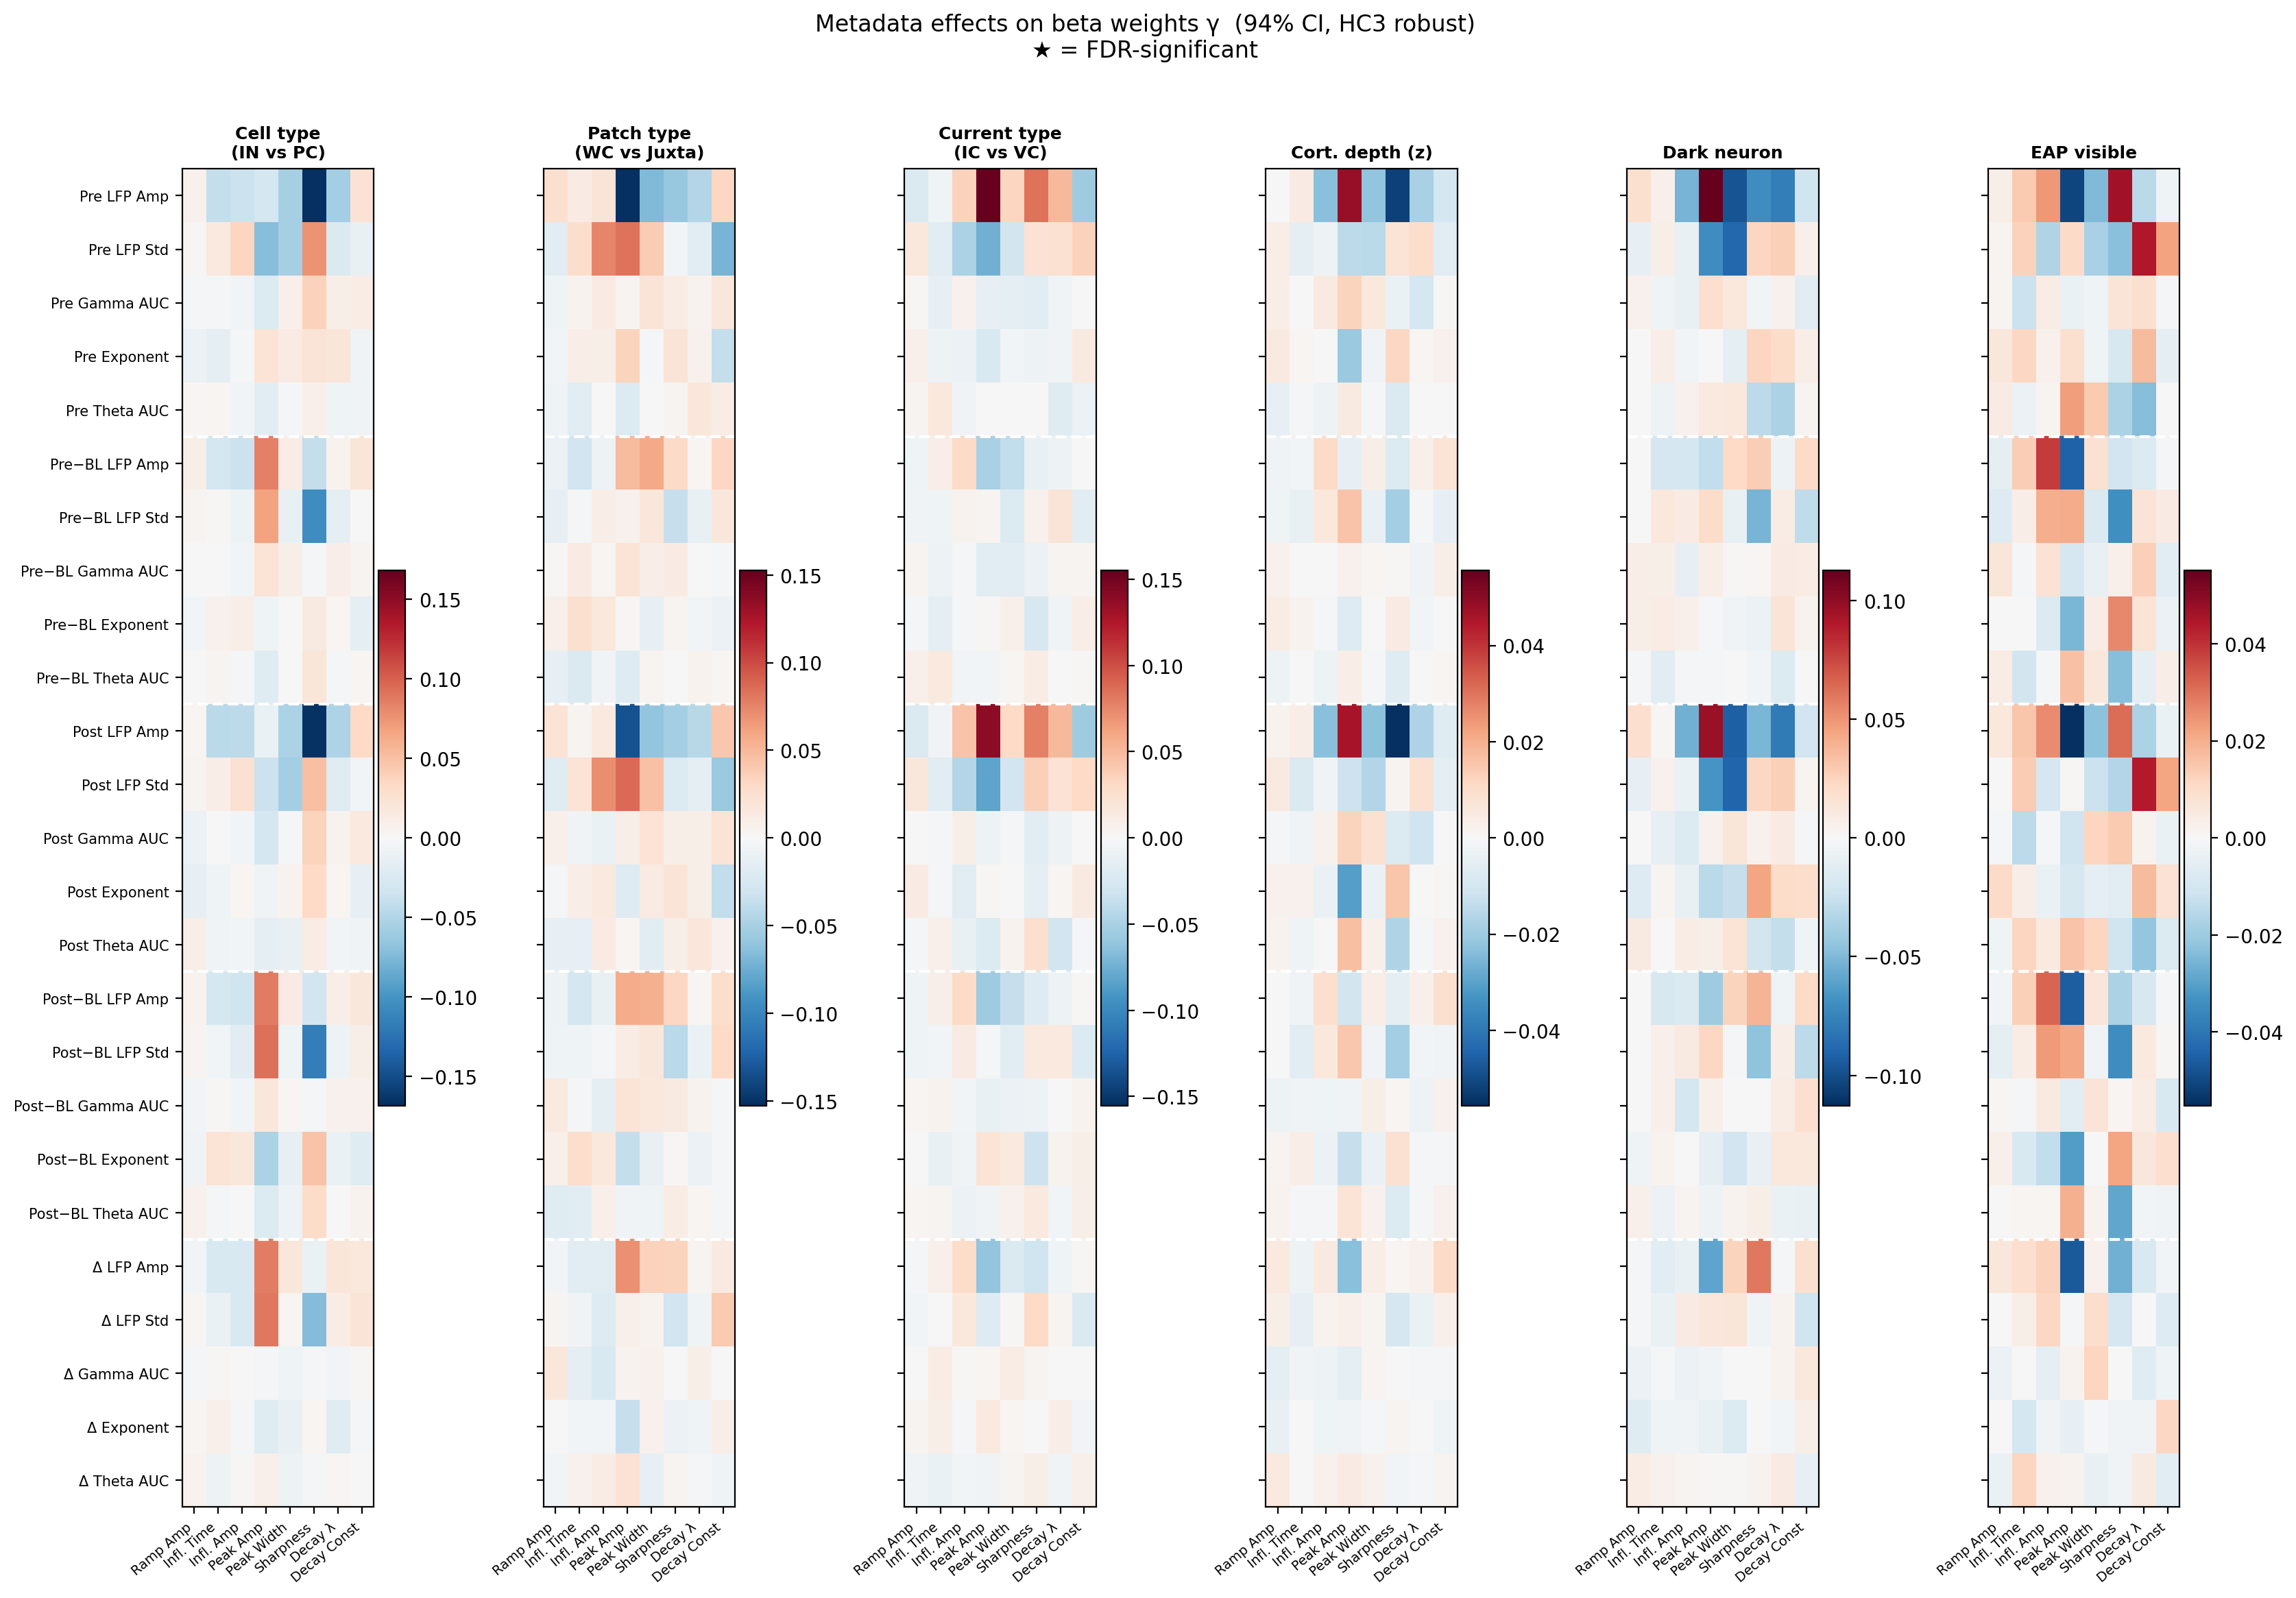

In [8]:
# ── Metadata effects heatmap ──────────────────────────────────────────────────
# γ for each metadata variable across (target × feature) pairs. ★ = FDR-significant.
plot_metadata_effects(df_mlm, target_labels)